In [1]:
#installation of libraries
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [80]:
#uploading dataset and inspecting dataset
df = pd.read_csv("Delivery_Logistics.csv")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)
display(df.head())
print("Column names:")
print(df.columns.tolist())
print("\nDataset information:")
df.info()
print("\nStatistical summary:")
display(df.describe(include="all"))


Number of rows: 25000
Number of columns: 15
Dataset shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


Column names:
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null 

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
count,25000.000000,25000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000,25000,25000,25000,25000.000000,25000.000000
unique,NaN,9,9,6,4,5,6,NaN,NaN,20,9,2,3,NaN,NaN
top,NaN,xpressbees,fragile items,ev bike,two day,west,foggy,NaN,NaN,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000016,no,delivered,NaN,NaN
freq,NaN,2826,2848,4218,6302,5095,4219,NaN,NaN,3118,6302,18331,18331,NaN,NaN
mean,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,150.390436,25.145898,NaN,NaN,NaN,NaN,3.666000,864.944579
std,7212.732314,NaN,NaN,NaN,NaN,NaN,NaN,86.409745,14.368663,NaN,NaN,NaN,NaN,1.149964,435.712593
min,250.990000,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,0.670000,NaN,NaN,NaN,NaN,1.000000,95.667400
25%,6250.750000,NaN,NaN,NaN,NaN,NaN,NaN,75.900000,12.680000,NaN,NaN,NaN,NaN,3.000000,490.800000
50%,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,151.000000,25.145000,NaN,NaN,NaN,NaN,4.000000,867.535000
75%,18750.250000,NaN,NaN,NaN,NaN,NaN,NaN,224.900000,37.660000,NaN,NaN,NaN,NaN,5.000000,1237.910000


In [81]:
#checking data quality
#missing values
'''missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().sum() / len(df) * 100
})

display(missing)'''
#duplicate records
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)


Dataset shape after removing duplicates:
(25000, 15)


In [82]:
#different categories
#delivery partners
print("Delivery Partners:")
print(df["delivery_partner"].value_counts())

Delivery Partners:
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64


In [75]:
#vehicle types
print("Vehicle Types:")
print(df["vehicle_type"].value_counts())

Vehicle Types:
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64


In [76]:
#delivery modes
print("Delivery Modes:")
print(df["delivery_mode"].value_counts())

Delivery Modes:
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64


In [49]:
#regions
print("Regions:")
print(df["region"].value_counts())

Regions:
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64


In [50]:
#weather condition
print("Weather Conditions:")
print(df["weather_condition"].value_counts())

Weather Conditions:
weather_condition
foggy     4219
stormy    4198
rainy     4171
cold      4158
hot       4130
clear     4124
Name: count, dtype: int64


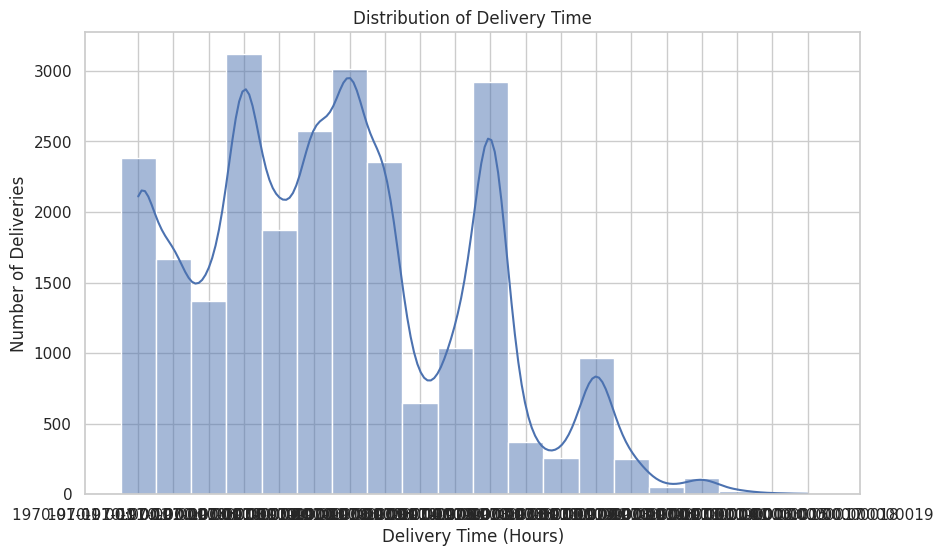

In [58]:
#delivery time
plt.figure(figsize=(10, 6))
sns.histplot(
    df["delivery_time_hours"],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Hours)")
plt.ylabel("Number of Deliveries")

plt.show()

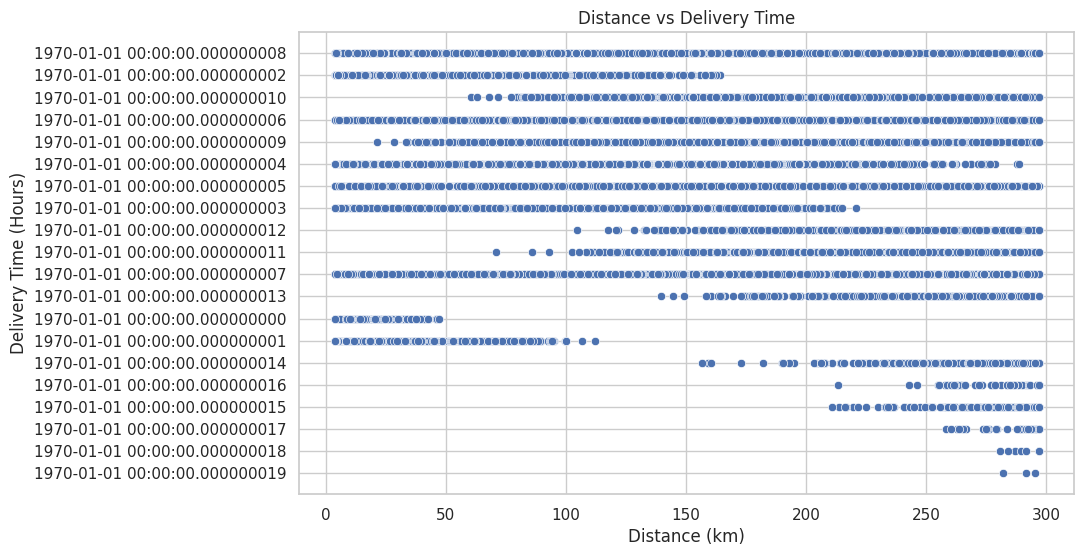

In [60]:
#distance vs delivery time
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="distance_km",
    y="delivery_time_hours",
    alpha=1
)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Hours)")
plt.show()

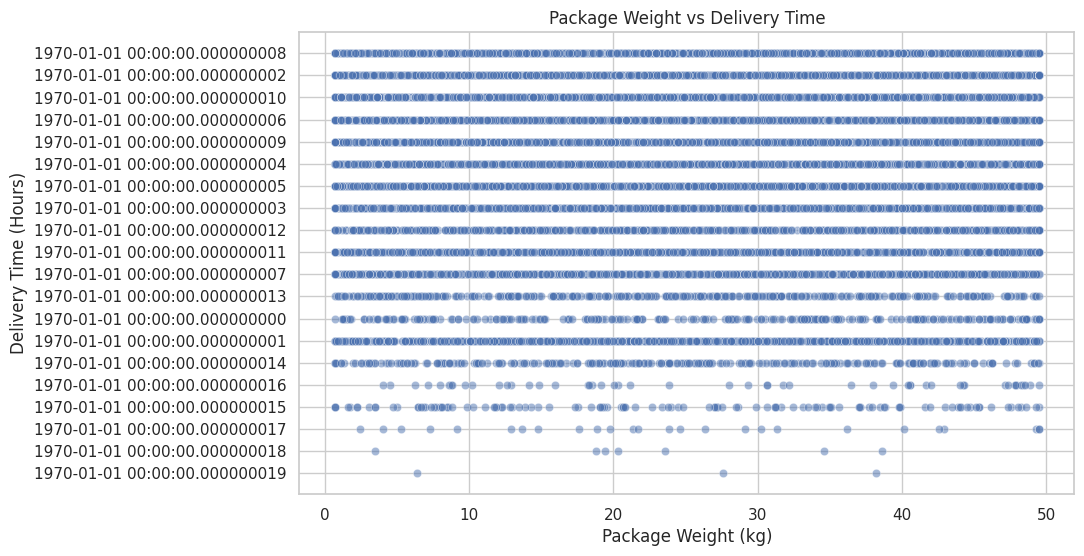

In [61]:
#Package Weight vs Delivery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="package_weight_kg",
    y="delivery_time_hours",
    alpha=0.5
)
plt.title("Package Weight vs Delivery Time")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Time (Hours)")
plt.show()

,delivery_time_hours
weather_condition,
stormy,8.807527
rainy,7.804843
foggy,6.486608
hot,4.784504
clear,4.776431
cold,4.773449


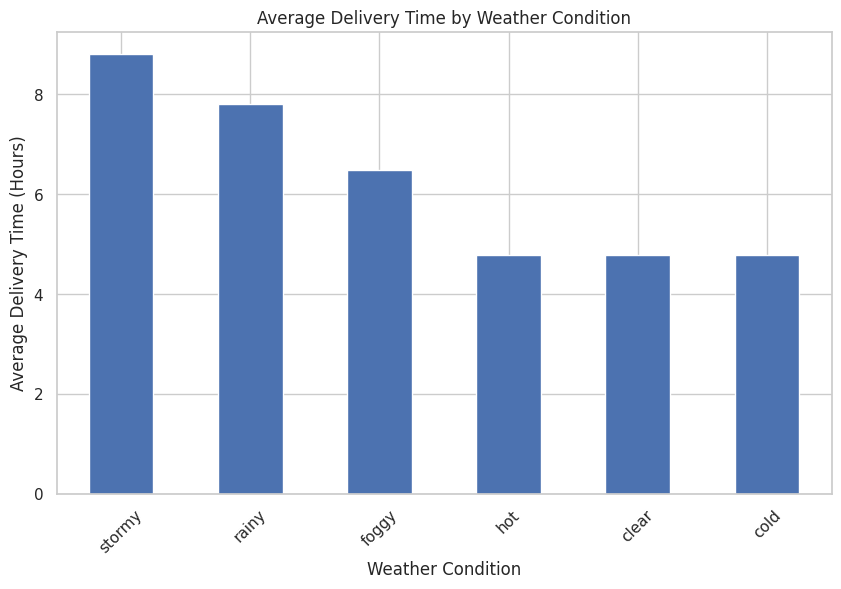

In [83]:
#weather vs delivery time
import re
import numpy as np
def parse_time_from_string(time_str):
    if pd.isna(time_str) or not isinstance(time_str, str):
        return np.nan

    match = re.search(r'(\d+)$', time_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            return np.nan
    return np.nan

df['delivery_time_hours'] = df['delivery_time_hours'].apply(parse_time_from_string)
df['expected_time_hours'] = df['expected_time_hours'].apply(parse_time_from_string)

weather_time = (
    df.groupby("weather_condition")[
        "delivery_time_hours"
    ]
    .mean()
    .sort_values(ascending=False)
)

display(weather_time)
plt.figure(figsize=(10, 6))

weather_time.plot(kind="bar")

plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (Hours)")

plt.xticks(rotation=45)

plt.show()

,delivery_time_hours
vehicle_type,
scooter,6.278869
bike,6.277644
van,6.267972
ev van,6.250000
truck,6.217129
ev bike,6.197013


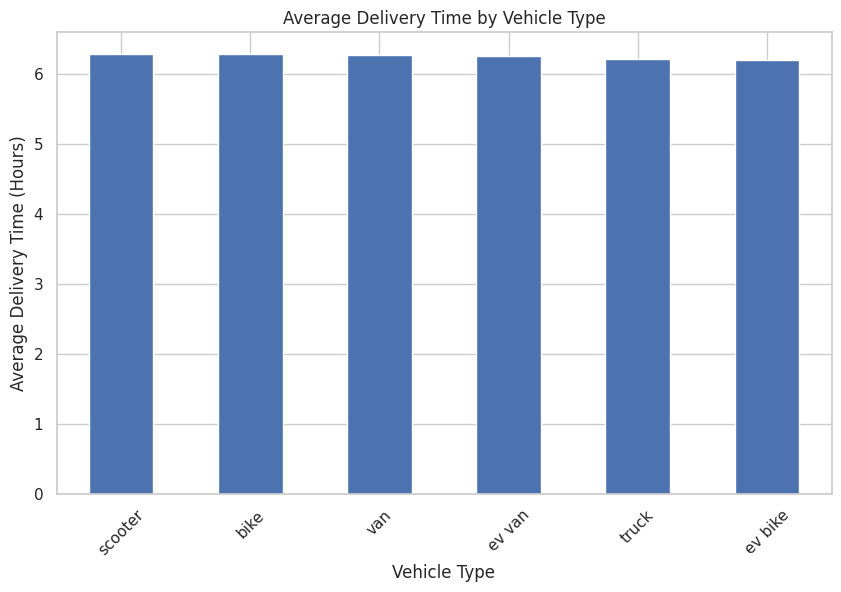

In [84]:
#vehicle type vs delivery time
vehicle_time = (
    df.groupby("vehicle_type")[
        "delivery_time_hours"
    ]
    .mean()
    .sort_values(ascending=False)
)

display(vehicle_time)
plt.figure(figsize=(10, 6))

vehicle_time.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (Hours)")

plt.xticks(rotation=45)

plt.show()

,delivery_time_hours
region,
west,6.296369
central,6.283004
north,6.249141
east,6.213458
south,6.196102


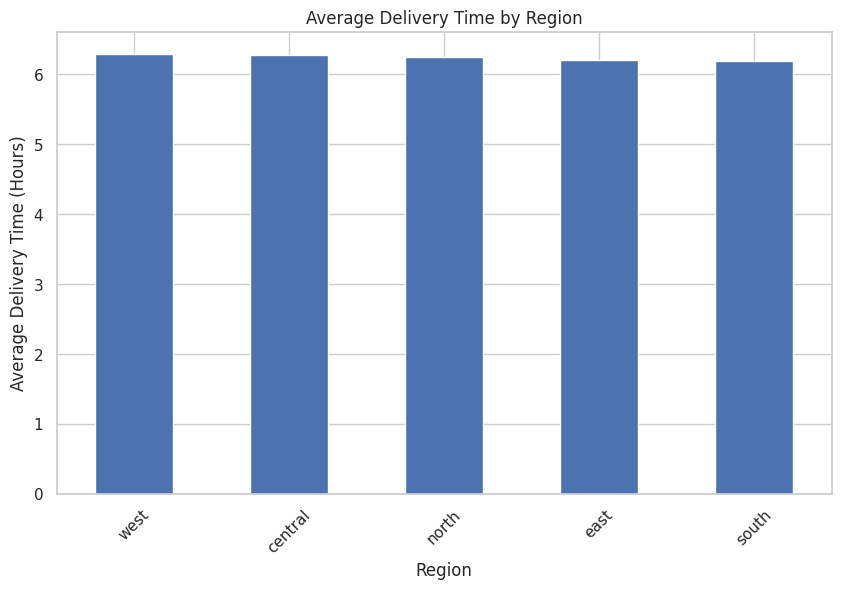

In [85]:
#region vs delivery timee
region_time = (
    df.groupby("region")[
        "delivery_time_hours"
    ]
    .mean()
    .sort_values(ascending=False)
)

display(region_time)
plt.figure(figsize=(10, 6))

region_time.plot(kind="bar")

plt.title("Average Delivery Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=45)

plt.show()

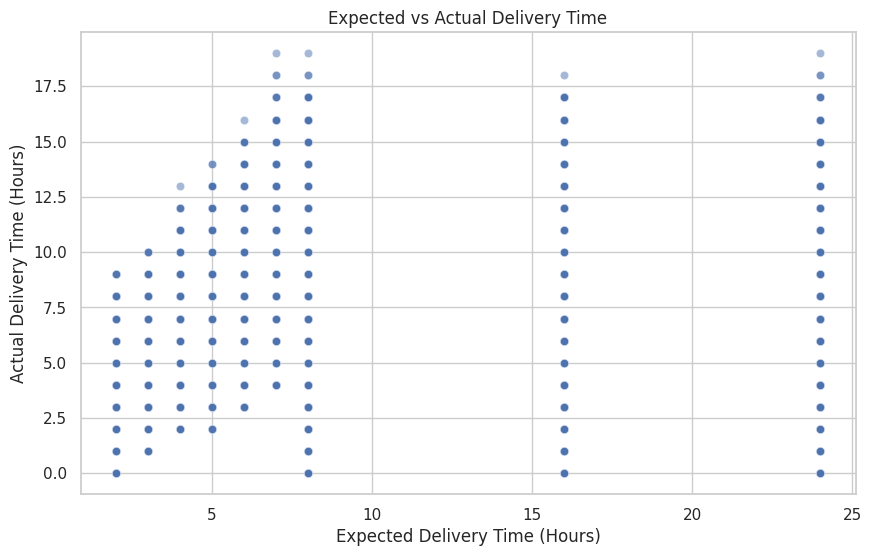

In [86]:
#expected vs actual delivery time
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="expected_time_hours",
    y="delivery_time_hours",
    alpha=0.5
)
plt.title("Expected vs Actual Delivery Time")
plt.xlabel("Expected Delivery Time (Hours)")
plt.ylabel("Actual Delivery Time (Hours)")
plt.show()

In [88]:
#delay analysis
print(df["delayed"].value_counts())
delay_percentage = (
    df["delayed"]
    .value_counts(normalize=True)
    * 100
)

display(delay_percentage)

delayed
no     18331
yes     6669
Name: count, dtype: int64


,proportion
delayed,
no,73.324
yes,26.676


In [97]:
#kpi-1 total delivery
total_deliveries = len(df)
print(
    "Total Deliveries:",
    total_deliveries
)
#kpi-2 average delivery time
average_delivery_time = (
    df["delivery_time_hours"].mean()
)
print(
    f"Average Delivery Time: "
    f"{average_delivery_time:.2f} hours"
)
#kpi-3 average distance
average_distance = (
    df["distance_km"].mean()
)
print(
    f"Average Distance: "
    f"{average_distance:.2f} km"
)
#kpi-4 average delivery cost
average_delivery_cost = (
    df["delivery_cost"].mean()
)
print(
    f"Average Delivery Cost: "
    f"{average_delivery_cost:.2f}"
)
#kpi-5 average package weight
average_package_weight = (
    df["package_weight_kg"].mean()
)
print(
    f"Average Package Weight: "
    f"{average_package_weight:.2f} kg"
)
#kpi-6 average delivery rating
average_delivery_rating = (
    df["delivery_rating"].mean()
)
print(
    f"Average Delivery Rating: "
    f"{average_delivery_rating:.2f}"
)

Total Deliveries: 25000
Average Delivery Time: 6.25 hours
Average Distance: 150.39 km
Average Delivery Cost: 864.94
Average Package Weight: 25.15 kg
Average Delivery Rating: 3.67


In [103]:
#kpi table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Deliveries",
        "Average Delivery Time (Hours)",
        "Average Distance (km)",
        "Average Delivery Cost",
        "Average Package Weight (kg)",
        "Average Delivery Rating"
    ],

    "Value": [
        total_deliveries,
        round(average_delivery_time, 2),
        round(average_distance, 2),
        round(average_delivery_cost, 2),
        round(average_package_weight, 2),
        round(average_delivery_rating, 2)
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Deliveries,25000.00
1,Average Delivery Time (Hours),6.25
2,Average Distance (km),150.39
3,Average Delivery Cost,864.94
4,Average Package Weight (kg),25.15
5,Average Delivery Rating,3.67


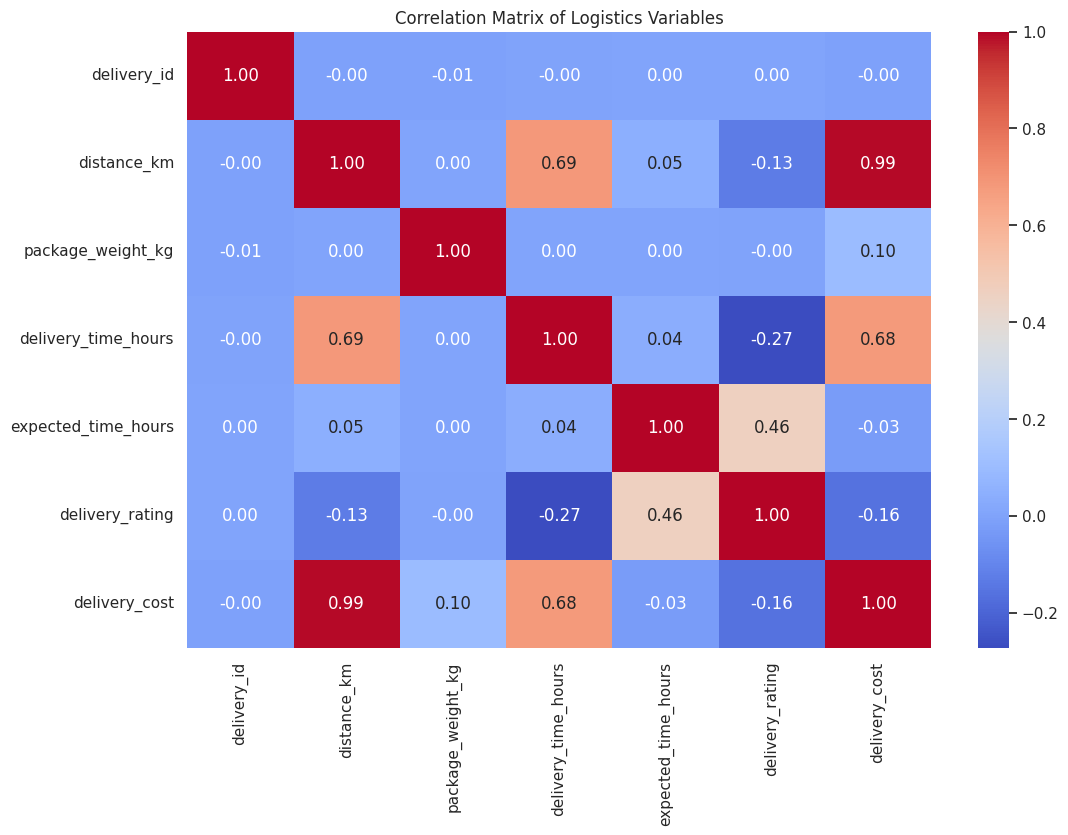

In [104]:
#correlation anlaysis
numeric_data = df.select_dtypes(
    include=np.number
)
correlation = numeric_data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Logistics Variables")
plt.show()